In [1]:
import json
import anndata as ad
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%load_ext autoreload
%autoreload 2

# INH

In [2]:
## MMC (ids and features)
datasetdic = {'minnie':{}, 'patchseq':{}}
featfiles = ['inh_{}_harmonized.h5ad'.format(key) for key in datasetdic.keys()]

for k, key in enumerate(datasetdic.keys()):
    curpath = os.path.join('/scratch/h5ad_outputs', featfiles[k])
    adata = ad.read_h5ad(curpath)

    df = pd.DataFrame(
        adata.X,
        columns=adata.var_names
    )
    datasetdic[key]['feats'] = df
    
    datasetdic[key]['id'] = adata.obs

In [7]:
datasetdic['patchseq']['id']

,cluster
0,L5 IT-2
1,L5 ET-2
2,L4 IT
3,L5 ET-3
4,L4/L5 IT
...,...
379,L6b
380,L6b
381,L6b
382,L6b


In [3]:
## MMC results
with open('/data/MMC-minnie-from-patchseq-v2/inh_mapping_wclusterHierachy.json', 'rb') as src:
    mapping = json.load(src)

In [4]:
mapping['results'][0]

{'cluster': {'assignment': 'Vip-MET-2',
  'bootstrapping_probability': 0.6428571428571429,
  'aggregate_probability': 0.6428571428571429,
  'avg_correlation': 0.728378026156421,
  'runner_up_assignment': ['Sncg-MET-2', 'Vip-MET-5'],
  'runner_up_correlation': [0.6694069872546865, 0.7408305368218224],
  'runner_up_probability': [0.21428571428571427, 0.14285714285714285],
  'directly_assigned': True},
 'cell_id': '252232'}

In [5]:
df = pd.DataFrame([
    {**item['cluster'], 'cell_id': item['cell_id']} 
    for item in mapping['results']
])

In [6]:
### add new column to dataframe with "other" label
df['assignment_masked'] = df['assignment'].where(df['aggregate_probability']< 0.5, other='other')

In [7]:
df.head()

,assignment,bootstrapping_probability,aggregate_probability,avg_correlation,runner_up_assignment,runner_up_correlation,runner_up_probability,directly_assigned,cell_id,assignment_masked
0,Vip-MET-2,0.642857,0.642857,0.728378,"[Sncg-MET-2, Vip-MET-5]","[0.6694069872546865, 0.7408305368218224]","[0.21428571428571427, 0.14285714285714285]",True,252232,other
1,Sncg-MET-2,0.357143,0.357143,0.531037,"[Vip-MET-2, Vip-MET-5, Lamp5-MET-1, Sst-MET-3,...","[0.5588892825756082, 0.5637448518458411, 0.578...","[0.25, 0.17857142857142858, 0.1071428571428571...",True,255120,Sncg-MET-2
2,Vip-MET-5,0.464286,0.464286,0.615556,"[Sncg-MET-2, Sst-MET-4, Lamp5-MET-1, Sst-MET-3]","[0.7427549474741542, 0.6736995599347343, 0.748...","[0.17857142857142858, 0.14285714285714285, 0.1...",True,255129,Vip-MET-5
3,Lamp5-MET-1,0.285714,0.285714,0.593101,"[Vip-MET-1, Sncg-MET-2, Sst-MET-3, Vip-MET-5, ...","[0.5256372557899643, 0.6909933369611316, 0.751...","[0.14285714285714285, 0.14285714285714285, 0.1...",True,255137,Lamp5-MET-1
4,Sncg-MET-2,0.321429,0.321429,0.619237,"[Vip-MET-2, Vip-MET-5, Vip-MET-1, Lamp5-MET-1]","[0.6175596448497921, 0.6976848718626856, 0.541...","[0.25, 0.14285714285714285, 0.1428571428571428...",True,255208,Sncg-MET-2


## distribution of predicted labels

/tmp/ipykernel_1517/3431935912.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


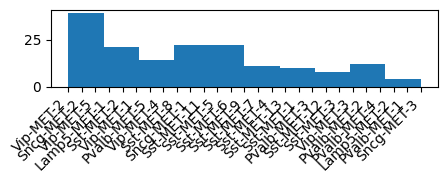

In [8]:
fig, ax = plt.subplots(figsize=[5,1])

ax.hist(df.assignment)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()

/tmp/ipykernel_1517/400623965.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


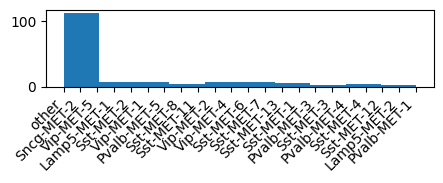

In [9]:
fig, ax = plt.subplots(figsize=[5,1])

ax.hist(df.assignment_masked)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()

### probability distribution per label

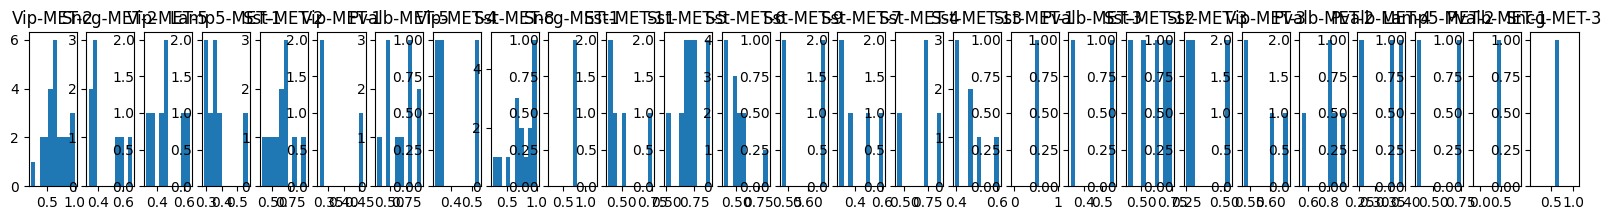

In [10]:
labels = df.assignment.unique()
numlabels = len(labels)

fig, axes = plt.subplots(nrows=1, ncols=numlabels, figsize=[20,2])

for a in range(numlabels):
    ax = axes[a]
    curlabel = labels[a]
    ax.hist(df.aggregate_probability[df.assignment==curlabel])
    #ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_title(curlabel)
plt.show()

## project in umap space with new labels and see if overlap

In [11]:
import umap
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.patches as mpatches
import colorcet as cc

In [12]:
scaler = StandardScaler()
X_ps = scaler.fit_transform(datasetdic['patchseq']['feats'])
X_mn = scaler.transform(datasetdic['minnie']['feats'])

reducer = umap.UMAP(n_components=2, random_state=42, init='random')
ps_emb = reducer.fit_transform(X_ps)
mn_emb = reducer.transform(X_mn)

/opt/conda/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [13]:
ps_labels = np.asarray(datasetdic['patchseq']['id']['cluster'].values.tolist())
mn_predicted = df.assignment_masked.values

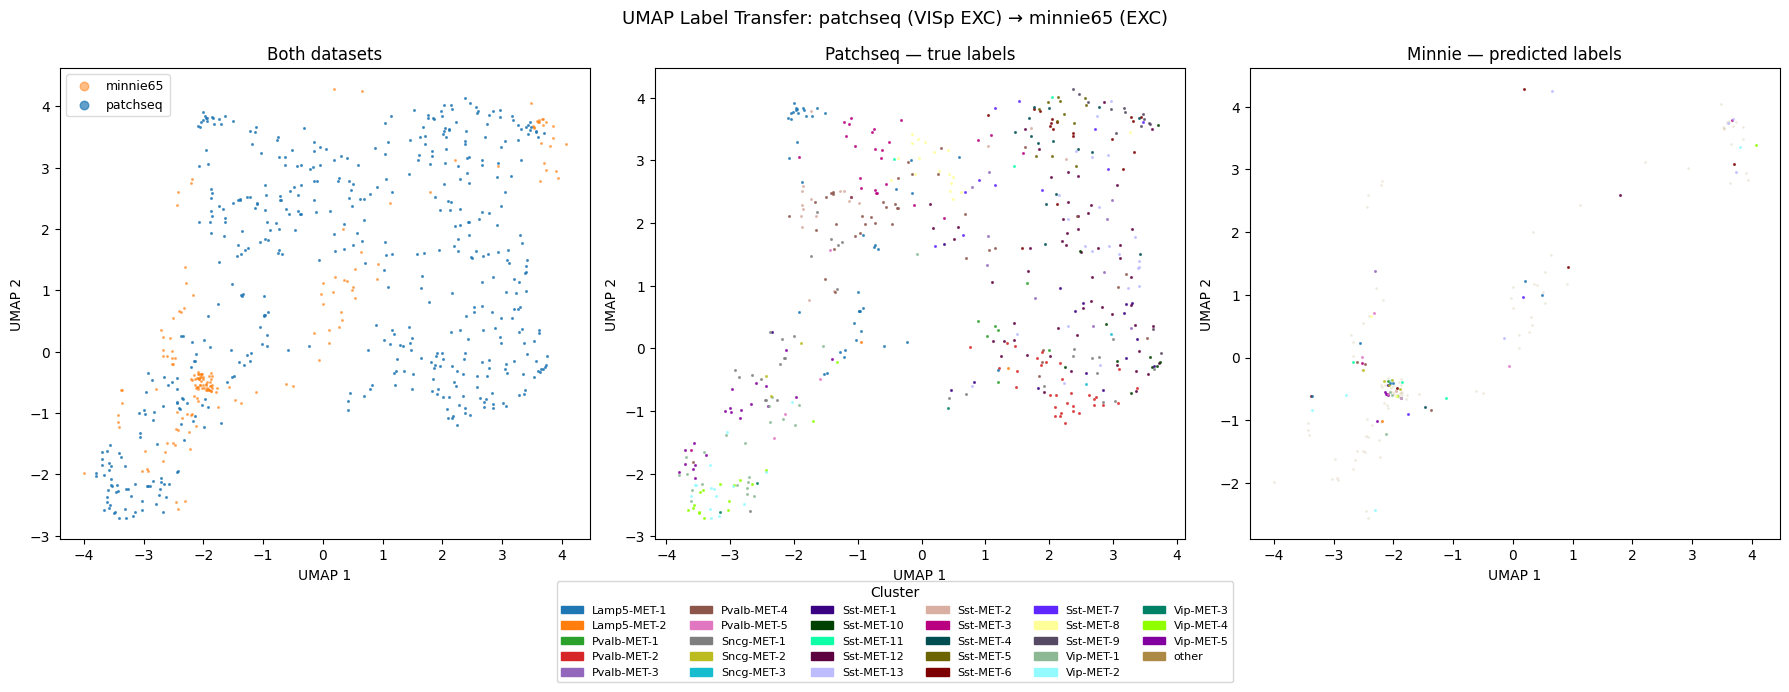

In [14]:
# ── Shared cluster colour map (tab20) ───────────────────────────────────────
all_cluster_labels = sorted(set(ps_labels) | set(mn_predicted))
colors = cc.b_glasbey_category10
cluster_colors = {lbl: colors[i% len(colors)] for i,lbl in enumerate (all_cluster_labels)}
# Dataset-identity colours for the left panel
DS_COLORS = {'patchseq': '#1f77b4', 'minnie65': '#ff7f0e'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Left: both datasets, coloured by dataset identity ────────────────────────
ax = axes[0]
ax.scatter(mn_emb[:, 0], mn_emb[:, 1],
           c=DS_COLORS['minnie65'], s=1.5, alpha=0.5, rasterized=True, label='minnie65')
ax.scatter(ps_emb[:, 0], ps_emb[:, 1],
           c=DS_COLORS['patchseq'], s=1.5, alpha=0.7, rasterized=True, label='patchseq')
ax.set_title('Both datasets')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(markerscale=5, framealpha=0.7, fontsize=9)

# ── Middle: patchseq, coloured by true cluster label ─────────────────────────
ax = axes[1]
for lbl in reversed(all_cluster_labels):
    mask = ps_labels == lbl
    if mask.any():
        ax.scatter(ps_emb[mask, 0], ps_emb[mask, 1],
                   c=[cluster_colors[lbl]], s=1.5, alpha=0.7, rasterized=True)
ax.set_title('Patchseq — true labels')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# ── Right: minnie, coloured by predicted cluster label ───────────────────────
ax = axes[2]
for lbl in reversed(all_cluster_labels):
    mask = mn_predicted == lbl
    curalpha = 0.1 if lbl == 'other' else 0.7
    if mask.any():
        ax.scatter(mn_emb[mask, 0], mn_emb[mask, 1],
                   c=[cluster_colors[lbl]], s=1.5, alpha=curalpha, rasterized=True)
ax.set_title('Minnie — predicted labels')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

# ── Shared cluster legend (below middle + right panels) ──────────────────────
handles = [mpatches.Patch(color=cluster_colors[lbl], label=lbl) for lbl in all_cluster_labels]
fig.legend(
    handles=handles, title='Cluster',
    loc='lower center', ncol=min(len(all_cluster_labels), 6),
    bbox_to_anchor=(0.5, -0.15), framealpha=0.8, fontsize=8
)

plt.suptitle('UMAP Label Transfer: patchseq (VISp EXC) → minnie65 (EXC)', fontsize=13)
plt.tight_layout()
plt.show()